In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/hemnathkandasamyk/healthy-lifestyle-csv/synthetic_health_lifestyle_dataset-selected-columns.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [3]:
df=pd.read_csv('/kaggle/input/datasets/hemnathkandasamyk/healthy-lifestyle-csv/synthetic_health_lifestyle_dataset-selected-columns.csv')

In [4]:
print(df.shape)

(7500, 10)


In [5]:
print(df.head())

   ID  Age  Gender  Height_cm  Weight_kg   BMI Smoker   Exercise_Freq  \
0   1   56   Other      177.6       37.3  11.8    Yes             NaN   
1   2   69   Other      169.3       70.7  24.7     No  1-2 times/week   
2   3   46  Female      159.1       69.0  27.3     No           Daily   
3   4   32    Male      170.6       76.4  26.3     No  3-5 times/week   
4   5   60    Male      158.4       60.4  24.1     No  3-5 times/week   

  Diet_Quality Alcohol_Consumption  
0         Poor                 NaN  
1         Good                High  
2    Excellent            Moderate  
3    Excellent            Moderate  
4    Excellent                 Low  


In [6]:
print(df.columns)

Index(['ID', 'Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Smoker',
       'Exercise_Freq', 'Diet_Quality', 'Alcohol_Consumption'],
      dtype='object')


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   7500 non-null   int64  
 1   Age                  7500 non-null   int64  
 2   Gender               7500 non-null   object 
 3   Height_cm            7500 non-null   float64
 4   Weight_kg            7500 non-null   float64
 5   BMI                  7500 non-null   float64
 6   Smoker               7500 non-null   object 
 7   Exercise_Freq        5621 non-null   object 
 8   Diet_Quality         7500 non-null   object 
 9   Alcohol_Consumption  5608 non-null   object 
dtypes: float64(3), int64(2), object(5)
memory usage: 586.1+ KB


In [8]:
df.describe()

,ID,Age,Height_cm,Weight_kg,BMI
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,3750.500000,43.653333,164.949467,70.036040,26.032493
std,2165.207842,14.911816,9.960921,14.741595,6.432411
min,1.000000,18.000000,124.500000,17.700000,6.500000
25%,1875.750000,31.000000,158.100000,59.900000,21.600000
50%,3750.500000,43.000000,164.900000,70.100000,25.600000
75%,5625.250000,57.000000,171.600000,80.100000,30.100000
max,7500.000000,69.000000,197.000000,128.500000,56.800000


In [9]:
df.isnull().sum()

ID                        0
Age                       0
Gender                    0
Height_cm                 0
Weight_kg                 0
BMI                       0
Smoker                    0
Exercise_Freq          1879
Diet_Quality              0
Alcohol_Consumption    1892
dtype: int64

In [10]:
df.dropna(inplace=True)

In [11]:
df.fillna(0, inplace=True)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.dtypes

ID                       int64
Age                      int64
Gender                  object
Height_cm              float64
Weight_kg              float64
BMI                    float64
Smoker                  object
Exercise_Freq           object
Diet_Quality            object
Alcohol_Consumption     object
dtype: object

In [15]:
df.drop(columns=["ID"], inplace=True)

In [16]:
df.dtypes

Age                      int64
Gender                  object
Height_cm              float64
Weight_kg              float64
BMI                    float64
Smoker                  object
Exercise_Freq           object
Diet_Quality            object
Alcohol_Consumption     object
dtype: object

In [17]:
print(df["Gender"].unique())
print(df["Smoker"].unique())
print(df["Exercise_Freq"].unique())
print(df["Diet_Quality"].unique())
print(df["Alcohol_Consumption"].unique())

['Other' 'Female' 'Male']
['No' 'Yes']
['1-2 times/week' 'Daily' '3-5 times/week']
['Good' 'Excellent' 'Poor' 'Average']
['High' 'Moderate' 'Low']


In [18]:
df["Smoker"] = df["Smoker"].map({
    "No": 0,
    "Yes": 1
})

In [19]:
df["Exercise_Freq"] = df["Exercise_Freq"].map({
    "1-2 times/week": 1,
    "3-5 times/week": 2,
    "Daily": 3
})

In [20]:
df["Diet_Quality"] = df["Diet_Quality"].map({
    "Poor": 1,
    "Average": 2,
    "Good": 3,
    "Excellent": 4
})

In [21]:
df["Alcohol_Consumption"] = df["Alcohol_Consumption"].map({
    "Low": 1,
    "Moderate": 2,
    "High": 3
})

In [22]:
df = pd.get_dummies(
    df,
    columns=["Gender"],
    dtype=int
)

In [23]:
print(df.head())

   Age  Height_cm  Weight_kg   BMI  Smoker  Exercise_Freq  Diet_Quality  \
1   69      169.3       70.7  24.7       0              1             3   
2   46      159.1       69.0  27.3       0              3             4   
3   32      170.6       76.4  26.3       0              2             4   
4   60      158.4       60.4  24.1       0              2             4   
5   25      167.7       62.0  22.0       0              3             3   

   Alcohol_Consumption  Gender_Female  Gender_Male  Gender_Other  
1                    3              0            0             1  
2                    2              1            0             0  
3                    2              0            1             0  
4                    1              0            1             0  
5                    2              1            0             0  


In [24]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 4197 entries, 1 to 7499
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  4197 non-null   int64  
 1   Height_cm            4197 non-null   float64
 2   Weight_kg            4197 non-null   float64
 3   BMI                  4197 non-null   float64
 4   Smoker               4197 non-null   int64  
 5   Exercise_Freq        4197 non-null   int64  
 6   Diet_Quality         4197 non-null   int64  
 7   Alcohol_Consumption  4197 non-null   int64  
 8   Gender_Female        4197 non-null   int64  
 9   Gender_Male          4197 non-null   int64  
 10  Gender_Other         4197 non-null   int64  
dtypes: float64(3), int64(8)
memory usage: 393.5 KB
None


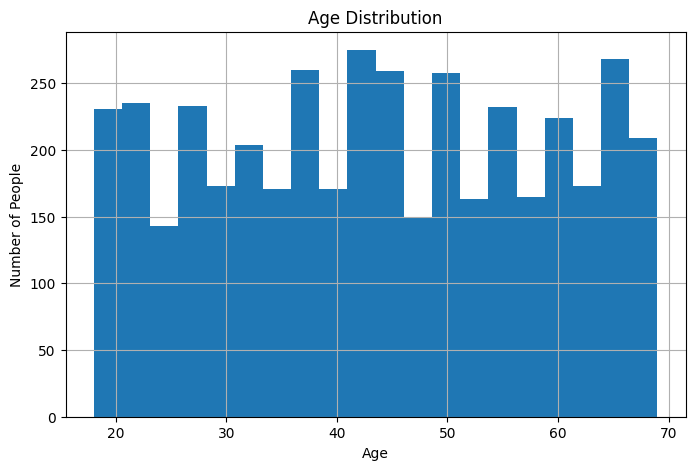

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of People")

plt.grid(True)

plt.show()

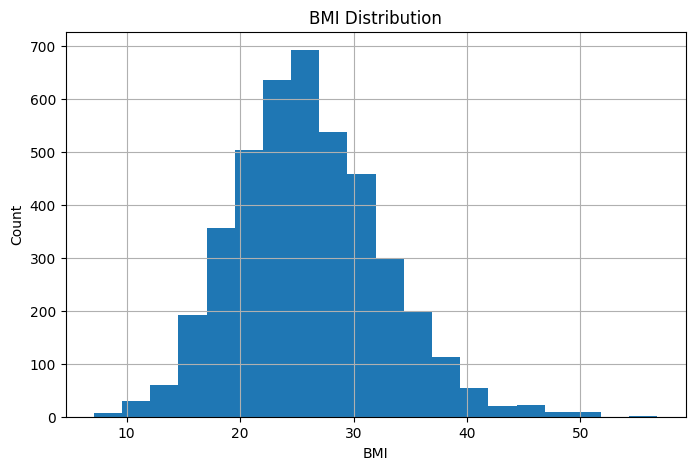

In [26]:
plt.figure(figsize=(8,5))

plt.hist(df["BMI"], bins=20)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Count")

plt.grid(True)

plt.show()

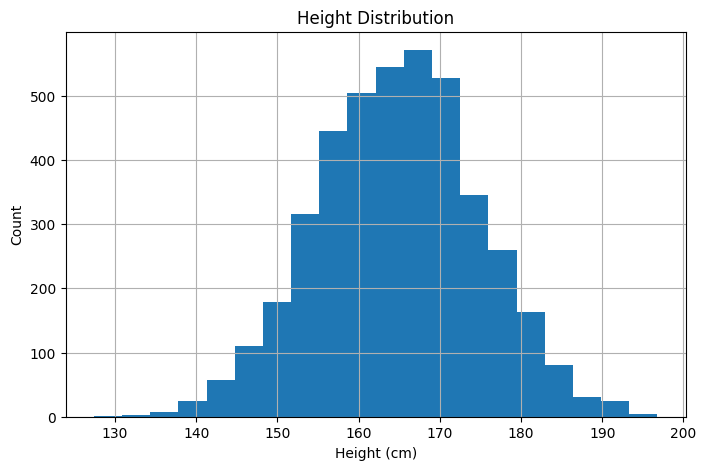

In [27]:
plt.figure(figsize=(8,5))

plt.hist(df["Height_cm"], bins=20)

plt.title("Height Distribution")
plt.xlabel("Height (cm)")
plt.ylabel("Count")

plt.grid(True)

plt.show()

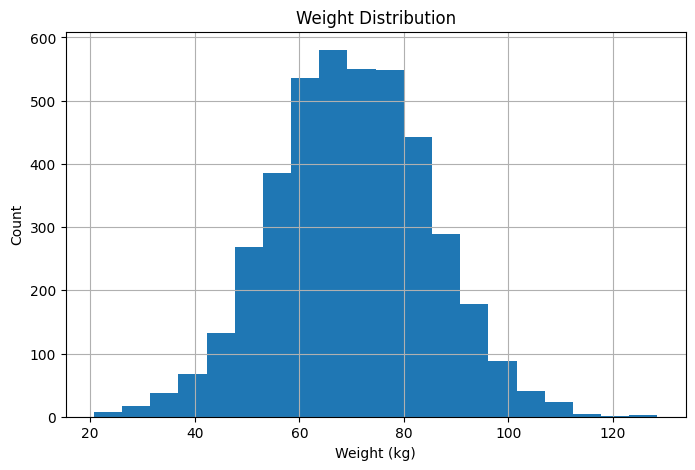

In [28]:
plt.figure(figsize=(8,5))

plt.hist(df["Weight_kg"], bins=20)

plt.title("Weight Distribution")
plt.xlabel("Weight (kg)")
plt.ylabel("Count")

plt.grid(True)

plt.show()

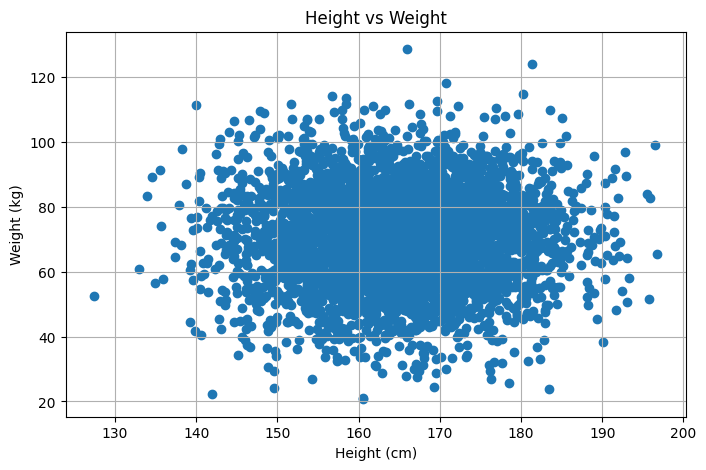

In [29]:
plt.figure(figsize=(8,5))

plt.scatter(df["Height_cm"], df["Weight_kg"])

plt.title("Height vs Weight")
plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")

plt.grid(True)

plt.show()

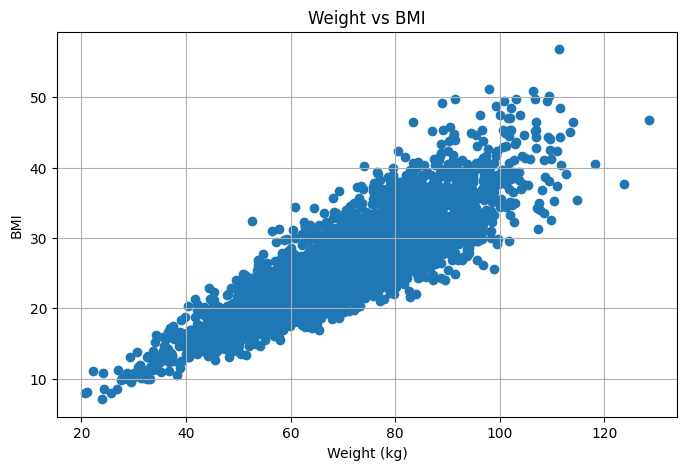

In [30]:
plt.figure(figsize=(8,5))

plt.scatter(df["Weight_kg"], df["BMI"])

plt.title("Weight vs BMI")
plt.xlabel("Weight (kg)")
plt.ylabel("BMI")

plt.grid(True)

plt.show()

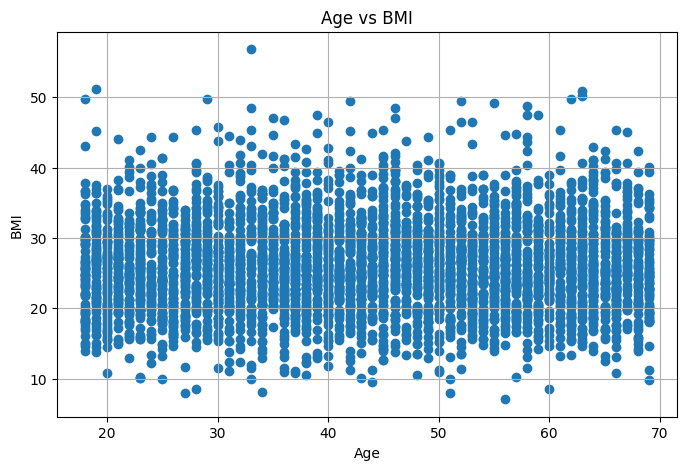

In [31]:
plt.figure(figsize=(8,5))

plt.scatter(df["Age"], df["BMI"])

plt.title("Age vs BMI")
plt.xlabel("Age")
plt.ylabel("BMI")

plt.grid(True)

plt.show()

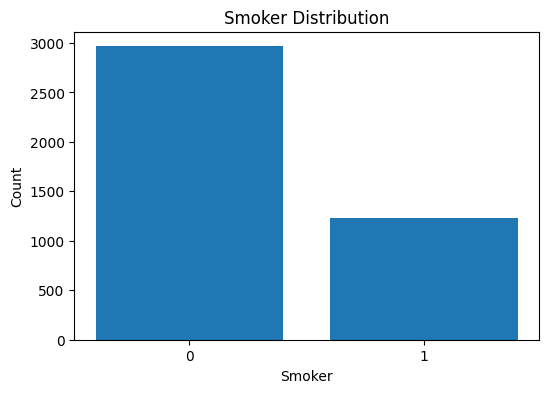

In [32]:
smoker_counts = df["Smoker"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(smoker_counts.index.astype(str), smoker_counts.values)

plt.title("Smoker Distribution")
plt.xlabel("Smoker")
plt.ylabel("Count")

plt.show()

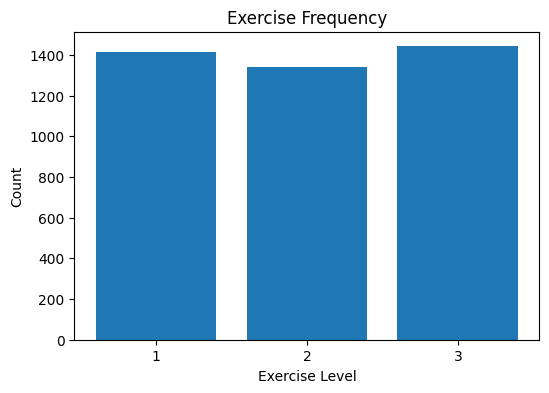

In [33]:
exercise_counts = df["Exercise_Freq"].value_counts().sort_index()

plt.figure(figsize=(6,4))

plt.bar(exercise_counts.index.astype(str), exercise_counts.values)

plt.title("Exercise Frequency")
plt.xlabel("Exercise Level")
plt.ylabel("Count")

plt.show()

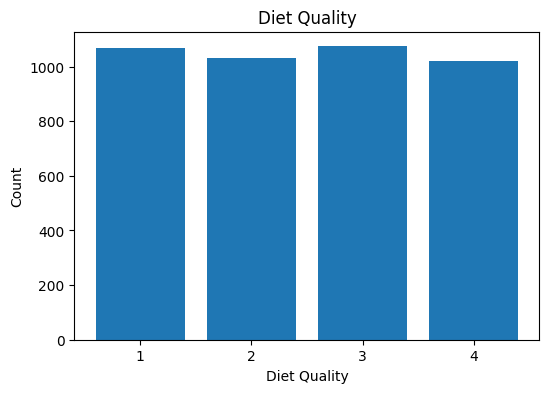

In [34]:
diet_counts = df["Diet_Quality"].value_counts().sort_index()

plt.figure(figsize=(6,4))

plt.bar(diet_counts.index.astype(str), diet_counts.values)

plt.title("Diet Quality")
plt.xlabel("Diet Quality")
plt.ylabel("Count")

plt.show()

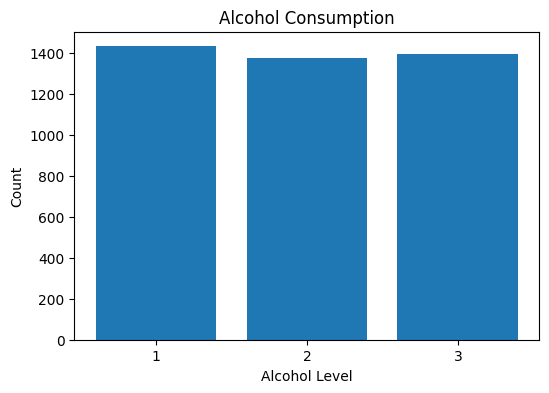

In [35]:
alcohol_counts = df["Alcohol_Consumption"].value_counts().sort_index()

plt.figure(figsize=(6,4))

plt.bar(alcohol_counts.index.astype(str), alcohol_counts.values)

plt.title("Alcohol Consumption")
plt.xlabel("Alcohol Level")
plt.ylabel("Count")

plt.show()

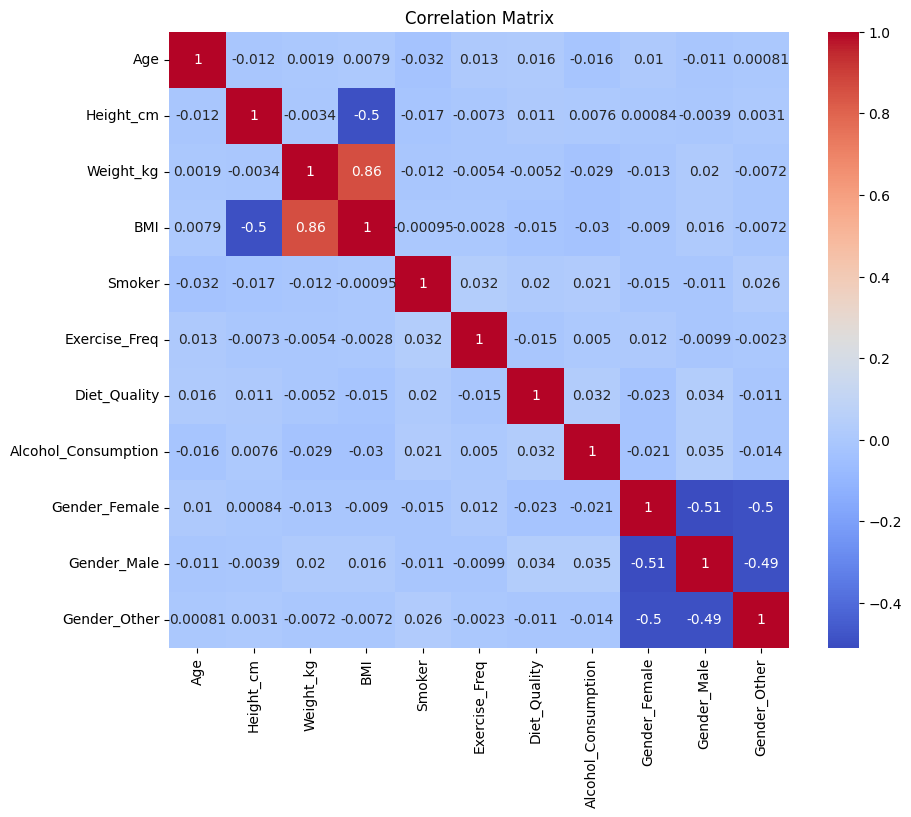

In [36]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

In [37]:
df.to_csv(
    "/kaggle/working/processed_health_dataset.csv",
    index=False
)

print("✅ Dataset saved successfully!")

✅ Dataset saved successfully!


In [38]:
import os

os.listdir("/kaggle/working")

['processed_health_dataset.csv', '__notebook__.ipynb']